# Project: Credit card customer risk prediction

## Analyze objective

1. Clean data across many features.  
2. Build a logistic regression model.

## Introduction

This dataset requires significant cleaning.  
This dataset contains multiple customer characteristics and can be used to predict whether a customer will be approved for a credit card.  
The description of variables:  
- checking_status：Status of the existing checking point.  
现有支票账户的状态  
- duration：Loan duration in months.  
贷款期限，单位月  
- credit_history：Credit history(e.g.,good record, on-time payment, delays).   
信用记录、按时还款、延迟还款、关键账户等信息  
- purpose：Purpose of the loan.  
- credit_amount：Loan amount.
- savings_status：Status of saving account / bonds.  
客户的储蓄or投资账户状态  
- employment：Current employment status, in years.  
在当前工作岗位的任职时长  
- installment_commitment：Monthly repayment amount as a percentage of disposable income.  
分期还款额占客户可支配收入的比例  
- personal_status：Gender and marital status.  
- other_parties：Other debtors / guarantors involved.  
- residence_since: Duration at current residence in years.
- property_magnitude: Type of property owned by the customer.
- other_payment_plans: Existance of other installment plans or debts.  
客户是否有其他分期付款计划or债务  
- housing: Type of housing the customer lives in.
- existing_credits: Num of existing credits(loans) the customer has.
- num_dependents: Num of people financially dependent on the customer.
- own_telephone: Whether the customer owns a telephone.
- foreign_worker: Whether the customer is a foreign worker.
- class: Target variable indicating if the credit is good or bad.

## Read data

In [1]:
import pandas as pd
ori_d = pd.read_csv("E:\\Python\\ori_dataset_Carmen\\credit_customers.csv")
ori_d.head(3)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good


## Evaluate and clean data

### Evaluate data tidiness

In [2]:
pd.set_option('display.max_columns', 21)
ori_d.sample(10)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
479,<0,15.0,critical/other existing credit,furniture/equipment,1478.0,<100,>=7,4.0,male single,none,4.0,car,44.0,none,own,2.0,skilled,2.0,yes,yes,good
801,0<=X<200,18.0,critical/other existing credit,radio/tv,1795.0,<100,>=7,3.0,female div/dep/mar,guarantor,4.0,real estate,48.0,bank,rent,2.0,unskilled resident,1.0,yes,yes,good
486,no checking,12.0,existing paid,radio/tv,3077.0,<100,1<=X<4,2.0,male single,none,4.0,car,52.0,none,own,1.0,skilled,1.0,yes,yes,good
346,0<=X<200,13.0,critical/other existing credit,radio/tv,882.0,<100,<1,4.0,male single,guarantor,4.0,real estate,23.0,none,own,2.0,skilled,1.0,none,yes,good
446,<0,36.0,existing paid,new car,1842.0,<100,<1,4.0,female div/dep/mar,none,4.0,car,34.0,none,own,1.0,skilled,1.0,yes,yes,bad
776,no checking,36.0,critical/other existing credit,new car,3535.0,<100,4<=X<7,4.0,male single,none,4.0,car,37.0,none,own,2.0,skilled,1.0,yes,yes,good
484,no checking,12.0,critical/other existing credit,new car,1163.0,500<=X<1000,1<=X<4,4.0,male single,none,4.0,real estate,44.0,none,own,1.0,skilled,1.0,yes,yes,good
164,no checking,36.0,existing paid,new car,909.0,500<=X<1000,>=7,4.0,male single,none,4.0,life insurance,36.0,none,own,1.0,skilled,1.0,none,yes,good
511,no checking,36.0,existing paid,used car,4686.0,<100,1<=X<4,2.0,male single,none,2.0,no known property,32.0,none,for free,1.0,high qualif/self emp/mgmt,1.0,yes,yes,good
61,0<=X<200,15.0,critical/other existing credit,radio/tv,1537.0,no known savings,>=7,4.0,male single,guarantor,4.0,real estate,50.0,none,own,2.0,skilled,1.0,yes,yes,good


Looking at a sample of 10 rows, the data confirms to NF-3.There are no structural issues.

### Evaluate data cleanliness

In [3]:
ori_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   object 
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   object 
 3   purpose                 1000 non-null   object 
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   object 
 6   employment              1000 non-null   object 
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   object 
 9   other_parties           1000 non-null   object 
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   object 
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   object 
 14  housing                 1000 non-null   o

- checking_status：Status of the existing checking point.  
现有支票账户的状态  
- duration：Loan duration in months.  
贷款期限，单位月  
- credit_history：Credit history(e.g.,good record, on-time payment, delays).   
信用记录、按时还款、延迟还款、关键账户等信息  
- purpose：Purpose of the loan.  
- credit_amount：Loan amount.
- savings_status：Status of saving account / bonds.  
客户的储蓄or投资账户状态  
- employment：Current employment status, in years.  
在当前工作岗位的任职时长  
- installment_commitment：Monthly repayment amount as a percentage of disposable income.  
分期还款额占客户可支配收入的比例  
- personal_status：Gender and marital status.  
- other_parties：Other debtors / guarantors involved.  
- residence_since: Duration at current residence in years.
- property_magnitude: Type of property owned by the customer.
- other_payment_plans: Existance of other installment plans or debts.  
客户是否有其他分期付款计划or债务  
- housing: Type of housing the customer lives in.
- existing_credits: Num of existing credits(loans) the customer has.
- num_dependents: Num of people financially dependent on the customer.
- own_telephone: Whether the customer owns a telephone.
- foreign_worker: Whether the customer is a foreign worker.
- class: Target variable indicating if the credit is good or bad.

From the output, there are a total of 1,000 observations.  
**There are no missing values.**  
`own_telephone`, `foreign_worker`, `class` **should be 'category'**.  
 We need too convey their types.

In [4]:
clean_d = ori_d.copy()
clean_d[['own_telephone', 'foreign_worker', 'class']] = clean_d[['own_telephone', 'foreign_worker', 'class']].astype("category")
clean_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   object  
 1   duration                1000 non-null   float64 
 2   credit_history          1000 non-null   object  
 3   purpose                 1000 non-null   object  
 4   credit_amount           1000 non-null   float64 
 5   savings_status          1000 non-null   object  
 6   employment              1000 non-null   object  
 7   installment_commitment  1000 non-null   float64 
 8   personal_status         1000 non-null   object  
 9   other_parties           1000 non-null   object  
 10  residence_since         1000 non-null   float64 
 11  property_magnitude      1000 non-null   object  
 12  age                     1000 non-null   float64 
 13  other_payment_plans     1000 non-null   object  
 14  housing                 1

#### Evaluate duplicated data

In [5]:
clean_d.duplicated().sum()

0

There is no duplicated data.

#### Evaluate inconsistent data

In [6]:
clean_d.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [7]:
clean_d['age'].sort_values()

391    19.0
633    19.0
513    20.0
155    20.0
410    20.0
       ... 
606    74.0
186    74.0
430    74.0
330    75.0
536    75.0
Name: age, Length: 1000, dtype: float64

In [8]:
clean_d.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## Analyze data

In [9]:
import statsmodels.api as sm

In [10]:
lr_d = clean_d.copy()
lr_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   object  
 1   duration                1000 non-null   float64 
 2   credit_history          1000 non-null   object  
 3   purpose                 1000 non-null   object  
 4   credit_amount           1000 non-null   float64 
 5   savings_status          1000 non-null   object  
 6   employment              1000 non-null   object  
 7   installment_commitment  1000 non-null   float64 
 8   personal_status         1000 non-null   object  
 9   other_parties           1000 non-null   object  
 10  residence_since         1000 non-null   float64 
 11  property_magnitude      1000 non-null   object  
 12  age                     1000 non-null   float64 
 13  other_payment_plans     1000 non-null   object  
 14  housing                 1

In [11]:
lr_d = pd.get_dummies(lr_d, columns=['checking_status', 'credit_history', 'purpose', 'savings_status',  'employment', 'personal_status', 'other_parties', 'property_magnitude', 
                        'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class'], dtype = int, 
              drop_first = True)
lr_d

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_<0,checking_status_>=200,checking_status_no checking,...,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_yes,foreign_worker_yes,class_good
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,1,0,0,...,1,0,1,0,1,0,0,1,1,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,0,0,0,...,1,0,1,0,1,0,0,0,1,0
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,0,1,...,1,0,1,0,0,0,1,0,1,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,1,0,0,...,1,0,0,0,1,0,0,0,1,1
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,1,0,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12.0,1736.0,3.0,4.0,31.0,1.0,1.0,0,0,1,...,1,0,1,0,0,0,1,0,1,1
996,30.0,3857.0,4.0,4.0,40.0,1.0,1.0,1,0,0,...,1,0,1,0,0,0,0,1,1,1
997,12.0,804.0,4.0,4.0,38.0,1.0,1.0,0,0,1,...,1,0,1,0,1,0,0,0,1,1
998,45.0,1845.0,4.0,4.0,23.0,1.0,1.0,1,0,0,...,1,0,0,0,1,0,0,1,1,0


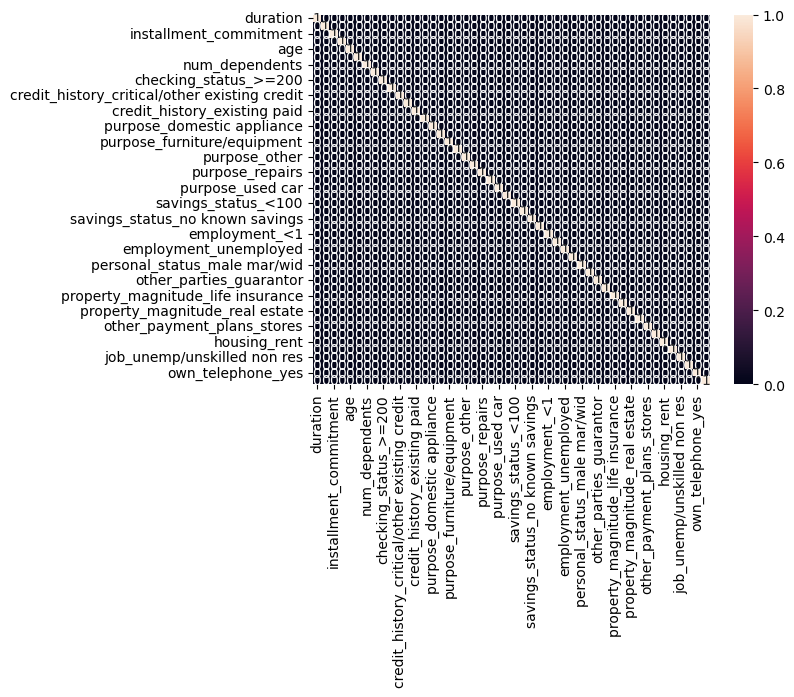

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

y = lr_d['class_good']
X = lr_d.drop('class_good', axis=1)
sns.heatmap(X.corr().abs() > 0.8, annot=True)
plt.show()

The variables aren't strongly correlated, so the model should converge without any issues.

In [14]:
X = sm.add_constant(X)

In [15]:
result = sm.Logit(y, X).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.447909
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             class_good   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      951
Method:                           MLE   Df Model:                           48
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                  0.2668
Time:                        18:12:57   Log-Likelihood:                -447.91
converged:                       True   LL-Null:                       -610.86
Covariance Type:            nonrobust   LLR p-value:                 5.755e-43
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                             2.3531      1.260      1.868      0.062      -0.116       4.822
duration                                         -0.0279      0.009     -2.997      0.003      -0.046      -0.010
credit_amount                                    -0.0001   4.44e-05     -2.887      0.004      -0.000   -4.12e-05
installment_commitment                           -0.3301      0.088     -3.739      0.000      -0.503      -0.157
residence_since                                  -0.0048      0.086     -0.055      0.956      -0.174       0.165
age                                               0.0145      0.009      1.576      0.115      -0.004       0.033
existing_credits                                 -0.2721      0.190     -1.436      0.151      -0.644       0.099
num_dependents                                   -0.2647      0.249     -1.062      0.288      -0.753       0.224
checking_status_<0                               -0.3749      0.218     -1.720      0.085      -0.802       0.052
checking_status_>=200                             0.5908      0.373      1.585      0.113      -0.140       1.321
checking_status_no checking                       1.3370      0.232      5.752      0.000       0.881       1.793
credit_history_critical/other existing credit     1.5791      0.438      3.605      0.000       0.721       2.438
credit_history_delayed previously                 0.9965      0.470      2.119      0.034       0.075       1.918
credit_history_existing paid                      0.7295      0.385      1.894      0.058      -0.025       1.484
credit_history_no credits/all paid                0.1434      0.549      0.261      0.794      -0.932       1.219
purpose_domestic appliance                       -0.2173      0.804     -0.270      0.787      -1.793       1.359
purpose_education                                -0.7764      0.466     -1.666      0.096      -1.690       0.137
purpose_furniture/equipment                       0.0515      0.354      0.145      0.884      -0.643       0.746
purpose_new car                                  -0.7401      0.334     -2.216      0.027      -1.395      -0.086
purpose_other                                     0.7487      0.800      0.936      0.349      -0.819       2.316
purpose_radio/tv                                  0.1515      0.337      0.450      0.653      -0.509       0.812
purpose_repairs                                  -0.5237      0.593     -0.883      0.377      -1.687       0.639
purpose_retraining                                1.3193      1.233      1.070      0.285      -1.097       3.736
purpose_used car                                  0.9264      0.441      2.101      0.036       0.062       1.791
savings_status_500<=X<1000                        0.0183      0.466      0.039      0.969      -0.894       0.931
savings_status_<100                              

LASSO,L1正则化，p-value的上位替代。需要精进数据分析的知识了，do a record.